# Q-learning for Cliff Walking

In this exercise you should apply Q-learning on the Cliff Walking problem from example 6.6 from page 132 in the book. In this problem the agent has to reach the goal state from the starting state. However, whenever an agent steps into one of the bottom states it falls of a cliff. This will yield a reward of -100 and the agent has to start over. You have to apply Q-learning on this problem.

In [1]:
import gymnasium as gym
import itertools
import matplotlib
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from lib.envs.cliff_walking import CliffWalkingEnv
matplotlib.style.use('ggplot')

In [2]:
env = CliffWalkingEnv()

Below we have given an incomplete implementation of the Q-learning algorithm, which you have to complete. The pseudocode for Q-learning is given on page 131 in the book by Sutton and Barto.

In [3]:
def q_learning(env, num_episodes, discount_factor=1.0, alpha=0.5, epsilon=0.1):
    """
    Q-Learning algorithm: Off-policy TD control. Finds the optimal greedy policy
    while following an epsilon-greedy policy
    
    Args:
        env: Gymnasium environment.
        num_episodes: Number of episodes to run for.
        discount_factor: Gamma discount factor.
        alpha: TD learning rate.
        epsilon: Chance to sample a random action. Float between 0 and 1.
    
    Returns:
        A tuple (Q, episode_lengths).
        Q is the optimal action-value function, a dictionary mapping state -> action values.
        stats is an EpisodeStats object with two numpy arrays for episode_lengths and episode_rewards.
    """
    
    # The final action-value function.
    # A nested dictionary that maps state -> (action -> action-value).
    nA = env.action_space.n
    Q = {}
    for s1 in range(env.shape[0]):
        for s2 in range(env.shape[1]):
            Q[(s1, s2)] = np.zeros(nA)

    # Keeps track of useful statistics
    episode_rewards = np.zeros(num_episodes)
    episode_lengths = np.zeros(num_episodes)
    
    # Loop over episodes
    for i in range(num_episodes):
        # Print every 100 episodes.
        if (i + 1) % 100 == 0:
            print("\rEpisode {}/{}.".format(i + 1, num_episodes), end="")
            sys.stdout.flush()
        
        # Reset the environment and pick the first action
        state = env.reset()
        
        # One step in the environment
        done = False
        t = 1
        while not done:          
            # Calculate the action probabilities for the current state
            action_probs = np.ones(nA) * epsilon / nA
            best_action = np.argmax(Q[state])
            action_probs[best_action] += (1.0 - epsilon)

            # Sample an action from the action probabilities
            action = np.random.choice(np.arange(len(action_probs)), p=action_probs)
    
            # Take a step
            next_state, reward, done, _ = env.step(action)

            # Update statistics
            episode_rewards[i] += reward
            episode_lengths[i] = t
            t += 1
            
            # TD Update
            best_next_action = np.argmax(Q[next_state])    
            td_target = reward + discount_factor * Q[next_state][best_next_action]
            td_delta = td_target - Q[state][action]
            Q[state][action] += alpha * td_delta
                
            # Update state
            state = next_state
    
    return Q, episode_rewards, episode_lengths

In [4]:
Q, episode_rewards, episode_lengths = q_learning(env, 10000, alpha=0.1, epsilon=0.01)

Episode 10000/10000.

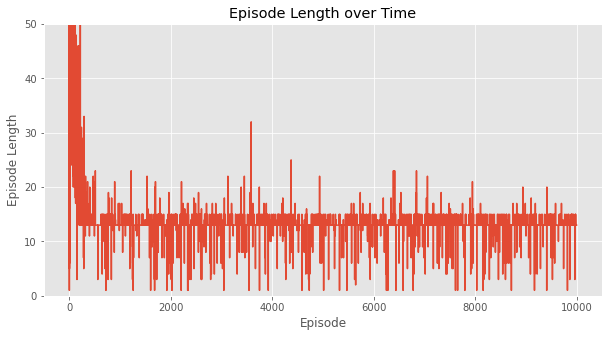

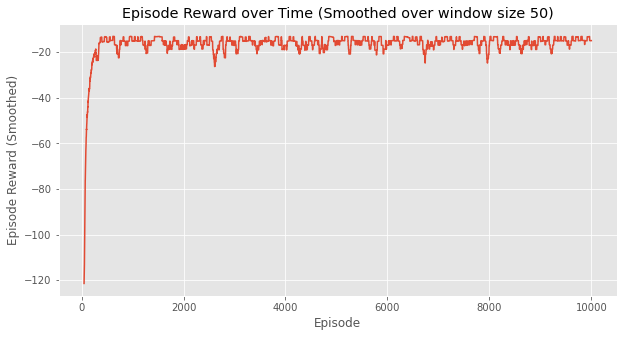

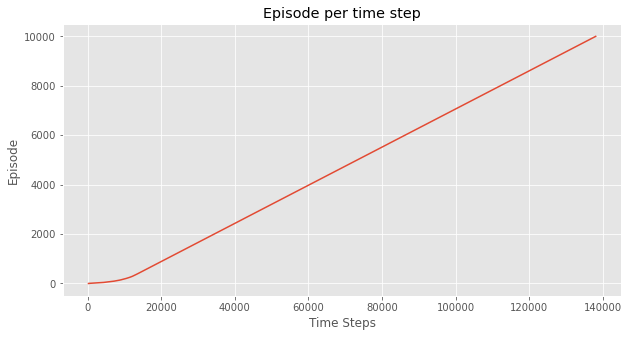

In [13]:
# Plot the episode length over time
fig1 = plt.figure(figsize=(10,5))
plt.plot(episode_lengths)
plt.ylim(ymin=0, ymax=50)
plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.title("Episode Length over Time")
plt.show(fig1)

# Plot the episode reward over time
fig2 = plt.figure(figsize=(10,5))
smooth_window = 50
rewards_smoothed = pd.Series(episode_rewards).rolling(smooth_window, min_periods=smooth_window).mean()
plt.plot(rewards_smoothed)
plt.ylim(ymin=-50, ymax=0)
plt.xlabel("Episode")
plt.ylabel("Episode Reward (Smoothed)")
plt.title("Episode Reward over Time (Smoothed over window size {})".format(smooth_window))
plt.show(fig2)

# Plot time steps and episode number
fig3 = plt.figure(figsize=(10,5))
plt.plot(np.cumsum(episode_lengths), np.arange(len(episode_lengths)))
plt.xlabel("Time Steps")
plt.ylabel("Episode")
plt.title("Episode per time step")
plt.show(fig3)